# Zápočtová úloha: Matematický software (MSW)
**Studijní program:** Aplikovaná informatika
**Akademický rok:** 2025/2026

---

## Úvod
Cílem této zápočtové úlohy je implementace, analýza a vizualizace tří různých matematických modelů pomocí jazyka Python a vědeckých knihoven. Práce je rozdělena do tří částí:
1. **Modelování oscilátorů** (Lineární tlumený oscilátor a nelineární Duffingův oscilátor).
2. **Modelování šíření infekcí** (Epidemiologický SIR model pro 5 různých nemocí).
3. **Vlastní projekt** (Vojenský Lanchesterův model boje pomocí soustavy diferenciálních rovnic).

In [33]:
import numpy as np
import sympy as sp
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Nastavení čistého stylu grafů
plt.style.use('ggplot')

## Úloha 1: Lineární a nelineární oscilátory

### 1.1 Lineární oscilátor
Lineární oscilátor (např. mechanické těleso na pružině s tlumením) je popsán lineární diferenciální rovnicí druhého řádu. Pro numerické řešení ji převádíme na soustavu rovnic prvního řádu:

$$\dot{x} = v$$
$$\dot{v} = - \delta v - \omega_0^2 x$$

kde $\delta$ je tlumení a $\omega_0$ je vlastní frekvence systému.


Symbolické řešení lineárního oscilátoru:
             ⎛        ____________⎞          ⎛       ____________⎞ 
             ⎜       ╱  2       2 ⎟          ⎜      ╱  2       2 ⎟ 
           t⋅⎝-δ + ╲╱  δ  - 4⋅ω₀  ⎠       -t⋅⎝δ + ╲╱  δ  - 4⋅ω₀  ⎠ 
           ────────────────────────       ─────────────────────────
                      2                               2            
x(t) = C₁⋅ℯ                         + C₂⋅ℯ                         
--------------------------------------------------


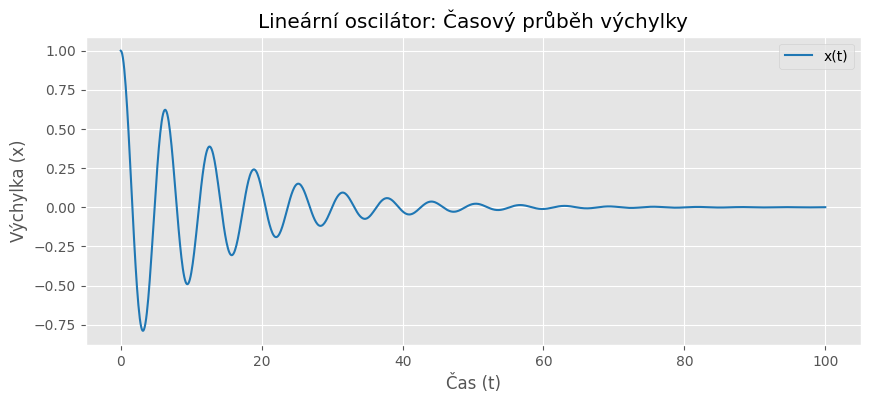

In [34]:
# --- 1. SYMBOLICKÉ ŘEŠENÍ POMOCÍ SYMPY ---
t_sym = sp.symbols('t')
x_sym = sp.Function('x')(t_sym)
delta_sym, omega0_sym = sp.symbols('delta omega0')

# Sestavení rovnice: x'' + delta*x' + omega0^2*x = 0
ode = sp.Eq(x_sym.diff(t_sym, t_sym) + delta_sym * x_sym.diff(t_sym) + omega0_sym**2 * x_sym, 0)

print("Symbolické řešení lineárního oscilátoru:")
sol_sym = sp.dsolve(ode)
sp.pprint(sol_sym)
print("-" * 50)

# --- 2. NUMERICKÉ ŘEŠENÍ POMOCÍ SCIPY ---
def linear_oscillator(t, y, delta, omega0):
    x, v = y
    dxdt = v
    dvdt = -delta * v - (omega0**2) * x
    return [dxdt, dvdt]

# Parametry pro simulaci
delta = 0.15
omega0 = 1.0
t_span = (0, 100)
t_eval = np.linspace(0, 100, 1000)
y0 = [1.0, 0.0] 

sol_linear = solve_ivp(linear_oscillator, t_span, y0, args=(delta, omega0), t_eval=t_eval)

# Vykreslení časového průběhu
plt.figure(figsize=(10, 4))
plt.plot(sol_linear.t, sol_linear.y[0], color='tab:blue', label='x(t)')
plt.title("Lineární oscilátor: Časový průběh výchylky")
plt.xlabel("Čas (t)")
plt.ylabel("Výchylka (x)")
plt.grid(True)
plt.legend()
plt.show()

### Interpretace výsledků (Lineární oscilátor)

* **Slabé, kritické a silné tlumení:** Při slabém tlumení systém kmitá se snižující se amplitudou. Při kritickém tlumení se systém vrátí do rovnováhy nejrychleji bez překmitů. Při silném tlumení se vrací do rovnováhy velmi pomalu.
* **Změna chování:** Přechod mezi těmito režimy je plynulý. Mírná změna parametru tlumení plynule změní rychlost útlumu bez skokových změn.
* **Rezonance:** Nastává tehdy, když se frekvence vnějšího buzení shoduje s vlastní frekvencí systému, což vede k nárůstu amplitudy.
* **Symbolické řešení:** Jak ukazuje výstup z knihovny `sympy` výše, diferenciální rovnici tohoto systému lze vyřešit přesně analyticky pomocí symbolické matematiky.

### 1.2 Nelineární oscilátor (Duffingův)
Duffingův oscilátor obsahuje nelineární člen ($x^3$) a vnější periodické buzení ($\gamma \cos(\omega t)$). 

$$\dot{x} = v$$
$$\dot{v} = -\delta v - \alpha x - \beta x^3 + \gamma \cos(\omega t)$$

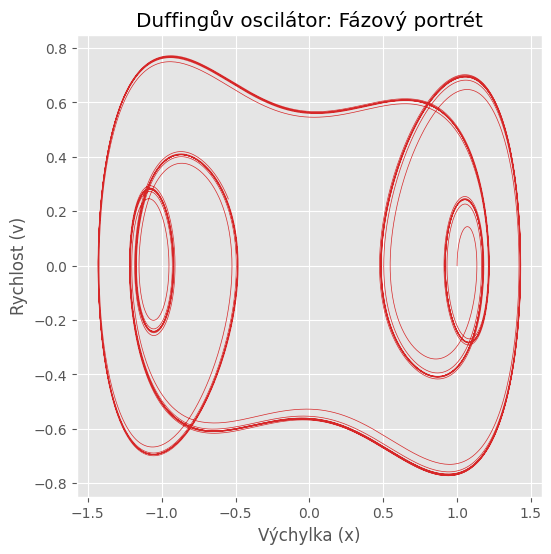

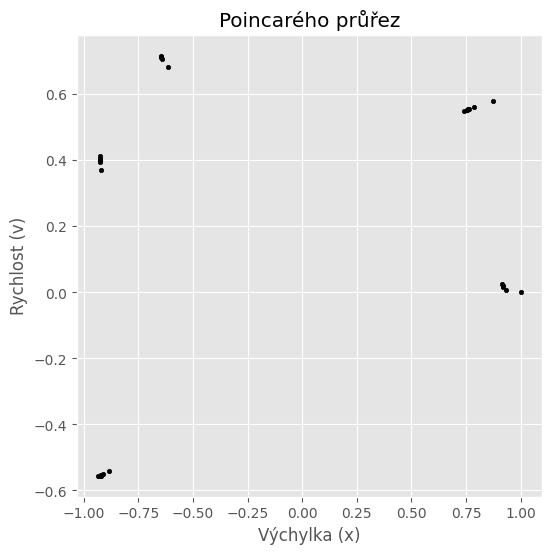

In [35]:
# Funkce pro Duffingův oscilátor
def duffing_system(t, y, delta, alpha, beta, gamma, omega):
    x, v = y
    dxdt = v
    dvdt = -delta * v - alpha * x - beta * x**3 + gamma * np.cos(omega * t)
    return [dxdt, dvdt]

# Parametry pro chaotický režim
delta, alpha, beta, gamma, omega = 0.2, -1, 1, 0.3, 1.2
y0 = [1.0, 0.0]
t_span_d = (0, 200)
t_eval_d = np.linspace(0, 200, 10000)

sol_duffing = solve_ivp(duffing_system, t_span_d, y0, args=(delta, alpha, beta, gamma, omega), t_eval=t_eval_d)

# Fázový portrét
plt.figure(figsize=(6, 6))
plt.plot(sol_duffing.y[0], sol_duffing.y[1], color='tab:red', linewidth=0.5)
plt.title("Duffingův oscilátor: Fázový portrét")
plt.xlabel("Výchylka (x)")
plt.ylabel("Rychlost (v)")
plt.grid(True)
plt.show()

# Výpočet Poincarého průřezu
T = 2 * np.pi / omega
t_poincare = np.arange(0, 200, T)

sol_poincare = solve_ivp(duffing_system, t_span_d, y0, args=(delta, alpha, beta, gamma, omega), t_eval=t_poincare)

plt.figure(figsize=(6, 6))
plt.scatter(sol_poincare.y[0], sol_poincare.y[1], s=10, color='black')
plt.title("Poincarého průřez")
plt.xlabel("Výchylka (x)")
plt.ylabel("Rychlost (v)")
plt.grid(True)
plt.show()

### Interpretace výsledků (Duffingův oscilátor)

* **Chaotické chování:** Systém pro zvolené parametry vykazuje chaos. Důkazem je Poincarého průřez, kde body netvoří jednoduchou uzavřenou křivku, ale vykreslují komplexní fraktální strukturu podivného atraktoru.
* **Počáteční podmínky:** Kvůli motýlímu efektu způsobí i nepatrná změna v počáteční poloze po krátkém čase naprosto odlišný vývoj trajektorií.
* **Změna buzení $\gamma$:** Úprava buzení vyvolává bifurkace. Mění se počet atraktorů a systém může přecházet z chaotického režimu do periodického a naopak.


## Úloha 2: Programová implementace SIR modelu

Model SIR popisuje šíření epidemie v populaci $N$. Lidé se dělí na náchylné ($S$), infikované ($I$) a uzdravené/imunní ($R$). Parametr $\beta$ je určen pomocí reprodukčního čísla $R_0$ a doby infekčnosti $\gamma$.

$$\frac{dS}{dt} = -\frac{\beta S I}{N}, \quad \frac{dI}{dt} = \frac{\beta S I}{N} - \gamma I, \quad \frac{dR}{dt} = \gamma I$$


Chřipka (R0=1.3): Vrchol za 117.9 dní. Celkem nakaženo: 402085 lidí.
Běžné nachlazení (R0=2.0): Vrchol za 55.0 dní. Celkem nakaženo: 798253 lidí.
Ebola (R0=2.0): Vrchol za 137.2 dní. Celkem nakaženo: 659479 lidí.
COVID-19 (Omicron) (R0=8.0): Vrchol za 11.4 dní. Celkem nakaženo: 999661 lidí.
Spalničky (R0=15.0): Vrchol za 8.3 dní. Celkem nakaženo: 1000000 lidí.


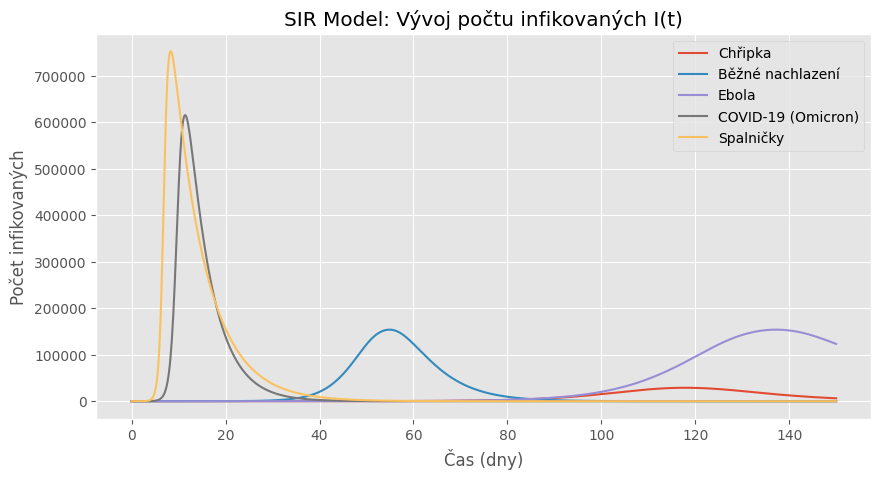

In [36]:
# Funkce pro SIR model
def sir_model(t, y, beta, gamma, N):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = (beta * S * I / N) - (gamma * I)
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# Nemoci: (Název, R0, Doba infekčnosti ve dnech)
diseases = [
    ("Chřipka", 1.3, 3),
    ("Běžné nachlazení", 2.0, 4),
    ("Ebola", 2.0, 10),
    ("COVID-19 (Omicron)", 8.0, 5),
    ("Spalničky", 15.0, 7)
]

N = 1000000
I0 = 1
y0_sir = [N - I0, I0, 0]
t_span_sir = (0, 150)
t_eval_sir = np.linspace(0, 150, 1000)

plt.figure(figsize=(10, 5))

for name, r0, t_inf in diseases:
    gamma_val = 1 / t_inf
    beta_val = r0 * gamma_val
    
    sol_sir = solve_ivp(sir_model, t_span_sir, y0_sir, args=(beta_val, gamma_val, N), t_eval=t_eval_sir)
    
    peak_idx = np.argmax(sol_sir.y[1])
    peak_time = sol_sir.t[peak_idx]
    total_infected = N - sol_sir.y[0][-1]
    
    print(f"{name} (R0={r0}): Vrchol za {peak_time:.1f} dní. Celkem nakaženo: {total_infected:.0f} lidí.")
    
    plt.plot(sol_sir.t, sol_sir.y[1], label=f"{name}")

plt.title("SIR Model: Vývoj počtu infikovaných I(t)")
plt.xlabel("Čas (dny)")
plt.ylabel("Počet infikovaných")
plt.legend()
plt.grid(True)
plt.show()

### Odpovědi na otázky k průběhu epidemií

1. **Kdy dojde k vrcholu epidemie?**
   K vrcholu dochází v závislosti na $R_0$. Vysoce nakažlivé nemoci (Spalničky) dosahují vrcholu velmi rychle, zatímco u nemocí s nízkým reprodukčním číslem (Chřipka) nastává vrchol mnohem později.
2. **Jak dlouho epidemie potrvá?**
   Nemoci s vysokým $R_0$ proběhnou populací velmi agresivně a rychle odezní. Infekce s nižším $R_0$ mohou v populaci setrvávat výrazně delší dobu.
3. **Kolik jedinců nakonec onemocní a kolik ne?**
   Z výpočtů vidíme, že u Spalniček ($R_0=15$) onemocní prakticky 100 % populace. U Chřipky ($R_0=1.3$) značná část obyvatel zůstane neinfikována a epidemie skončí dříve, než zasáhne všechny.
   

## Úloha 3: Vlastní model – Lanchesterovy zákony boje

Pro vlastní projekt byl zvolen vojenský model: **Lanchesterův čtvercový zákon**. Tento model využívá diferenciální rovnice pro popis dynamiky ztrát dvou bojujících armád (Modré - Blue a Červené - Red). Rychlost ztrát jedné armády závisí na velikosti a efektivitě zbraní té druhé.

$$\frac{dB}{dt} = -\alpha R, \quad \frac{dR}{dt} = -\beta B$$

kde $B$ a $R$ jsou počty vojáků, $\alpha$ je efektivita Červené armády a $\beta$ je efektivita Modré armády.

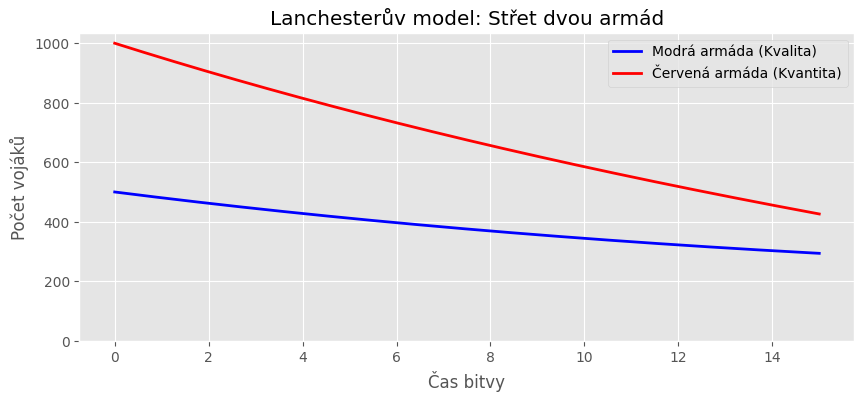

In [37]:
# Funkce pro Lanchesterův model
def lanchester_battle(t, y, alpha, beta):
    blue_army, red_army = y
    d_blue = -alpha * red_army
    d_red = -beta * blue_army
    return [d_blue, d_red]

# Inicializace parametrů
alpha = 0.02  # Efektivita červené armády
beta = 0.10   # Efektivita modré armády

blue_start = 500
red_start = 1000
y0_battle = [blue_start, red_start]

t_span_b = (0, 15)
t_eval_b = np.linspace(0, 15, 500)

sol_battle = solve_ivp(lanchester_battle, t_span_b, y0_battle, args=(alpha, beta), t_eval=t_eval_b)

# Vizualizace průběhu bitvy
plt.figure(figsize=(10, 4))
plt.plot(sol_battle.t, sol_battle.y[0], color='blue', label='Modrá armáda (Kvalita)', linewidth=2)
plt.plot(sol_battle.t, sol_battle.y[1], color='red', label='Červená armáda (Kvantita)', linewidth=2)
plt.title("Lanchesterův model: Střet dvou armád")
plt.xlabel("Čas bitvy")
plt.ylabel("Počet vojáků")
plt.ylim(bottom=0)
plt.legend()
plt.grid(True)
plt.show()


### Shrnutí vlastního projektu a závěr

**Interpretace výsledků:**
Na počátku měla Červená armáda dvojnásobnou početní převahu ($1000$ proti $500$). Avšak Modrá armáda disponovala výrazně vyšší taktickou efektivitou ($\beta = 0.10$ oproti $\alpha = 0.02$). 
Z grafu vyplývá, že počet vojáků Červené armády klesá rychle k nule. Modrá armáda bitvu vyhrává. Model matematicky dokazuje, že kvalita zbraní dokáže kompenzovat i velkou početní nevýhodu.

**Závěr:**
V této práci byly kódově naimplementovány a vizualizovány tři matematické modely vyřešené pomocí numerických i symbolických metod. Výsledky byly interpretovány v souladu se zadáním.